# Grad-CAM Validation & ROI Agreement

**Production pipeline this notebook implements and tests:**

```
full mammogram (ANY size) -> preprocess -> model -> Grad-CAM -> heatmap at the ORIGINAL size
```

The model takes **only the full image**. The cropped lesion patch and the ROI mask are
training-time signals; neither is needed here. The ROI mask appears in this notebook purely as
*ground truth to score the heatmap against* -- it is never fed to the model.

### The three questions this notebook answers

1. **Does the heatmap come back at the right size?** The model sees a 384x640 padded tensor, but a
   user hands us e.g. a 3024x5063 mammogram. The explanation must be overlayable on *their* image,
   so the padding has to be stripped and the map resized back. `cam_to_original` inverts the
   preprocessing geometry exactly. (Section 1.)
2. **Is the heatmap actually pointing at the lesion?** Measured, not eyeballed -- pointing game,
   energy concentration, concentration-ratio-vs-chance, IoU and pixel AP against the ROI masks.
   (Sections 3-5.)
3. **Which of the four architectures explains itself best?** All four v4 control checkpoints
   (`densenet121`, `efficientnet_b2`, `resnet50`, `vgg16`) are scored on the same test images, then
   ranked with paired significance tests and a multiple-comparison correction. (Section 6.)

### Why measurement matters

Nearly every CBIS-DDSM paper that shows Grad-CAM shows three hand-picked heatmaps and asserts they
look right. A quantified, statistically tested localization result is a stronger contribution than
a couple of points of accuracy -- and unlike accuracy, it is largely within our control.

Ranking backbones by *interpretability* rather than accuracy is the part that is genuinely novel
here, and it is only meaningful because sections 1 and 3 first establish that the measurement
itself is sound: the geometry round-trips exactly, CAM peaks track a known input patch, and a
randomly-initialized model scores at chance.

### What runs

`MODE = "single"` loads the four trained hi-res single-input control checkpoints from
`models/v4_hires_control_gap/`. These are the deployable models, so the numbers below are the real
ones to quote.

A dual-input teacher path (`MODE = "teacher"`) is kept for reference only: it zeroes the crop
branch and runs far from the 224x224 it was trained at, so its scores land just above a random
model and must not appear in the thesis.

No seg-aux hi-res checkpoint exists yet, so section 7's control-vs-segaux comparison no-ops until
one is trained.

In [32]:
import os, sys, warnings


def _find_repo_root(markers=("models", "dataframes", "notebooks")):
    """Walk up from the CWD until all markers are found. os.path.abspath("../..") only works if
    the Jupyter kernel's working directory is exactly notebooks/explainability -- VS Code's
    Jupyter extension does not always start it there (it can default to the workspace root), which
    silently sends every path built from ROOT to the wrong place, models/ included."""
    d = os.path.abspath(os.getcwd())
    for _ in range(6):
        if all(os.path.isdir(os.path.join(d, m)) for m in markers):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    raise RuntimeError(f"could not locate the repo root by walking up from {os.getcwd()!r} -- "
                       "expected to find models/, dataframes/ and notebooks/ somewhere above it")


ROOT = _find_repo_root()
sys.path.insert(0, os.path.join(ROOT, "notebooks", "common"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import hires_lib as H

warnings.filterwarnings("ignore", category=FutureWarning)
Image.MAX_IMAGE_PIXELS = None

PNG_ROOT = os.path.join(ROOT, "cbis_ddsm_png")
CKPT_DIR = os.path.join(ROOT, "notebooks", "experiment_1_baseline", "checkpoints")
NB_DIR = os.path.join(ROOT, "notebooks", "explainability")
RESULTS_DIR = os.path.join(NB_DIR, "results")
FIG_DIR = os.path.join(NB_DIR, "figures")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

H.set_seed()
print("kernel cwd:", os.getcwd())
print("repo root :", ROOT)
print("torch", torch.__version__, "| device", H.DEVICE)
print(f"cache {H.HIRES_W} x {H.HIRES_H} (W x H)")

kernel cwd: c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment\notebooks\explainability
repo root : c:\Users\Drew\Documents\University\2025-2026\2nd Semester\Thesis\Experiment
torch 2.11.0+cu128 | device cuda
cache 384 x 640 (W x H)


In [33]:
test_df = pd.read_csv(os.path.join(ROOT, "dataframes", "test_df_hires.csv"))
val_df = pd.read_csv(os.path.join(ROOT, "dataframes", "val_df_hires.csv"))
print("test:", len(test_df), "| val:", len(val_df))

_BS = chr(92)


def winlong(p):
    """CBIS-DDSM's nested DICOM UID folders blow past Windows MAX_PATH."""
    p = os.path.abspath(p)
    return (_BS * 2 + "?" + _BS + p) if not p.startswith(_BS * 2) else p


def source_path(row):
    return os.path.join(PNG_ROOT, str(row["image file path"]).replace("/", os.sep))


_size_cache = {}


def source_size(row):
    """(W, H) of the ORIGINAL png. Cached -- reopening a 15MP png per call is slow."""
    p = source_path(row)
    if p not in _size_cache:
        with Image.open(winlong(p)) as im:
            _size_cache[p] = im.size
    return _size_cache[p]


print("example source size (W x H):", source_size(test_df.iloc[0]))

test: 319 | val: 317
example source size (W x H): (3552, 5944)


## 1. The production path

`explain(image_path)` is the deployable function: raw image in, probability + original-resolution
heatmap out. Everything else exists to test it.

`cam_to_original` inverts `fit_pad`. The geometry is fully determined by the source dimensions, so
no state has to be carried between preprocessing and postprocessing.

In [34]:
def preprocess(pil_gray):
    """Raw PIL image -> (1,3,640,384) normalized tensor, identical geometry to the cache builder,
    so a model trained on the cache sees exactly this at inference."""
    canvas = H.fit_pad(pil_gray, Image.LANCZOS)
    t = H.TF.to_tensor(canvas)
    return H.TF.normalize(t.expand(3, -1, -1).clone(), H.IMAGENET_MEAN, H.IMAGENET_STD).unsqueeze(0)


def explain(image_path, cam_fn, class_idx=1):
    """THE PRODUCTION CALL.

    Returns (prob_malignant, heatmap) where heatmap.shape == (orig_H, orig_W) -- the size of the
    image the caller supplied, NOT the 384x640 preprocessed size.
    """
    with Image.open(winlong(image_path)) as im:
        pil = im.convert("L")
        ow, oh = pil.size
        x = preprocess(pil).to(H.DEVICE)
    cam, probs = cam_fn(x, class_idx=class_idx)
    return float(probs[0, 1]), H.cam_to_original(cam[0], ow, oh)


print("explain() returns a heatmap at the ORIGINAL image resolution.")

explain() returns a heatmap at the ORIGINAL image resolution.


### Round-trip check

A synthetic marker at a known fraction of the source must return to that same fraction after
`fit_pad` -> `cam_to_original`, across the real aspect ratios in the dataset.

In [35]:
print(f"{'source (WxH)':>18} | {'padded core':>13} | {'returned (WxH)':>15} | rel. error (x, y)")
worst = 0.0
for (ow, oh) in [(2986, 5356), (3024, 5063), (4144, 6736), (2041, 4384), (3552, 5944)]:
    nw, nh, ox, oy = H.fit_pad_geometry(ow, oh)
    cam = np.zeros((H.HIRES_H, H.HIRES_W), np.float32)
    cy, cx = oy + int(nh * 0.35), ox + int(nw * 0.65)
    yy, xx = np.ogrid[:H.HIRES_H, :H.HIRES_W]
    cam[(yy - cy) ** 2 + (xx - cx) ** 2 <= 8 ** 2] = 1.0
    back = H.cam_to_original(cam, ow, oh)
    py, px = np.unravel_index(np.argmax(back), back.shape)
    ey, ex = abs(py / oh - 0.35), abs(px / ow - 0.65)
    worst = max(worst, ey, ex)
    print(f"{ow:8d}x{oh:<8d} | {nw:4d}x{nh:<7d} | {back.shape[1]:6d}x{back.shape[0]:<7d} | "
          f"({ex:.4f}, {ey:.4f})")
assert worst < 0.02, f"round-trip error {worst:.4f} too large"
print(f"\nworst relative error {worst:.4f} -- output size matches input size exactly")

      source (WxH) |   padded core |  returned (WxH) | rel. error (x, y)
    2986x5356     |  357x640     |   2986x5356    | (0.0070, 0.0102)
    3024x5063     |  382x640     |   3024x5063    | (0.0075, 0.0101)
    4144x6736     |  384x624     |   4144x6736    | (0.0081, 0.0111)
    2041x4384     |  298x640     |   2041x4384    | (0.0106, 0.0101)
    3552x5944     |  382x640     |   3552x5944    | (0.0073, 0.0102)

worst relative error 0.0111 -- output size matches input size exactly


## 2. Load the models

All four v4 control checkpoints (`densenet121`, `efficientnet_b2`, `resnet50`, `vgg16`) from
`models/v4_hires_control_gap/`, trained identically -- same 640x384 cache, same GAP pooling, same
alpha, same seed 42, same batch size. Only the backbone differs, which is what makes the
architecture comparison in section 6 a fair one.

Every section below loops over `ARCHS`. `ARCH` is only the default argument for `load_model()`.

In [36]:
MODE = "single"          # "teacher" | "single"
ARCHS = ["densenet121", "efficientnet_b2", "resnet50", "vgg16"]
ARCH = ARCHS[0]          # default for load_model(); no section depends on it being densenet

# Colour is bound to the ARCHITECTURE, not to its rank, so a backbone keeps its hue in every
# figure and re-sorting never repaints the others. Checked for colourblind separation: worst
# adjacent pair dE 9.1 under protanopia. (The green/red pair this notebook previously used for
# the class split is dE 1.2 under deuteranopia -- one colour to those readers. Replaced.)
ARCH_COLOR = dict(zip(ARCHS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
CLASS_COLOR = {1: "#eb6834", 0: "#2a78d6"}      # malignant / benign
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

V4_DIR = os.path.join(ROOT, "models", "v4_hires_control_gap")


def single_ckpt_path(arch):
    return os.path.join(V4_DIR, f"hires_control_gap_a0.5_{arch}.pth")


class TeacherFullBranch(torch.nn.Module):
    """Exposes the teacher's full-image branch with a SingleInputModel-shaped interface so the
    identical Grad-CAM code runs on both. The crop branch is zero-filled: we are explaining what
    the full-image pathway responds to, and the deployed model has no crop at all."""

    def __init__(self, teacher):
        super().__init__()
        self.teacher = teacher
        # drop the trailing AdaptiveAvgPool2d so `extractor` yields a SPATIAL map
        self.extractor = torch.nn.Sequential(*[m for m in teacher.full_extractor
                                               if not isinstance(m, torch.nn.AdaptiveAvgPool2d)])

    def forward(self, x):
        spatial = self.extractor(x)
        f = torch.flatten(torch.nn.functional.adaptive_avg_pool2d(spatial, 1), 1)
        return self.teacher.classifier(torch.cat([f, torch.zeros_like(f)], dim=1))


def load_model(arch=None, mode=None, ckpt=None):
    """Parameterized so every section can reload once per architecture. The pooling/use_seg flags
    come from the checkpoint, never from a notebook constant -- a mismatch there loads without
    error and silently changes what is being explained."""
    arch = arch or ARCH
    mode = mode or MODE
    if mode == "teacher":
        m = TeacherFullBranch(H.load_teacher(arch, CKPT_DIR)).to(H.DEVICE).eval()
        return m, f"teacher full-branch ({arch})"
    ckpt = ckpt or single_ckpt_path(arch)
    ck = torch.load(ckpt, map_location=H.DEVICE, weights_only=False)
    assert list(ck.get("input_size", [])) == [H.HIRES_H, H.HIRES_W], (
        f"checkpoint input_size {ck.get('input_size')} != {[H.HIRES_H, H.HIRES_W]}. A 224-trained "
        "state dict loads without error at 640x384 and is silently wrong.")
    assert ck.get("arch", arch) == arch, f"checkpoint arch {ck.get('arch')} != requested {arch}"
    m = H.SingleInputModel(arch, pooling=ck.get("pooling", "gap"),
                           use_seg=ck.get("use_seg", False)).to(H.DEVICE)
    m.load_state_dict(ck["model_state_dict"])
    m.eval()
    return m, f"{arch} ({os.path.basename(ckpt)})"


# --- preflight: every checkpoint loads, and what explanation resolution does each buy? ---
# Failing here costs seconds; failing inside section 5 costs the whole sweep.
grid_rows = []
for arch in ARCHS:
    m, _ = load_model(arch=arch)
    with torch.no_grad():
        probe = m.extractor(torch.zeros(1, 3, H.HIRES_H, H.HIRES_W, device=H.DEVICE))
    gh, gw = int(probe.shape[-2]), int(probe.shape[-1])
    grid_rows.append({"arch": arch, "feat_ch": int(probe.shape[1]), "cam_grid": f"{gh}x{gw}",
                      "cells": gh * gw,
                      "cell_px": f"{H.HIRES_H // gh}x{H.HIRES_W // gw}"})
    del probe, m
    H.free_gpu()

GRID_TBL = pd.DataFrame(grid_rows)
print(GRID_TBL.to_string(index=False))
print("\ncam_grid IS the resolution of the explanation -- an upper bound on how precisely an")
print("architecture can point, before any question of whether it points correctly.")

           arch  feat_ch cam_grid  cells cell_px
    densenet121     1024    20x12    240   32x32
efficientnet_b2     1408    20x12    240   32x32
       resnet50     2048    20x12    240   32x32
          vgg16      512    20x12    240   32x32

cam_grid IS the resolution of the explanation -- an upper bound on how precisely an
architecture can point, before any question of whether it points correctly.


**That grid is the resolution of the explanation, and it is an architecture property.** On the old
224 cache it was 7x7 with the median lesion at 19x10 px -- smaller than one cell, so Grad-CAM could
not have localized a lesion even in principle. At 640x384 each of these backbones downsamples by
32, giving a 20x12 grid with the lesion at 35x34 px: about one cell. Coarse, but now genuinely
capable of pointing.

Because all four share that grid, none of them has a built-in resolution advantage -- any
difference in the localization scores below comes from what the backbone *learned*, not from how
finely it can express an answer.

## 3. Correctness checks before trusting any number

A localization metric that scores high for a random model is measuring the *dataset*, not the
model. These run first so the numbers that follow mean something. Check (a) is architecture-
specific (a random model's spatial statistics depend on its conv stem), so it runs once per
checkpoint in `ARCHS`. Check (b) tests the CAM-upsampling geometry itself, which is the same code
path regardless of backbone, so it runs once against a synthetic network.

In [37]:
def load_mask(row):
    return np.array(Image.open(row[H.ROI_HIRES_COL]).convert("L")) > 127


def tensor_from_cached(row):
    t = H.TF.to_tensor(Image.open(row[H.FULL_HIRES_COL]).convert("L"))
    return H.TF.normalize(t.expand(3, -1, -1).clone(), H.IMAGENET_MEAN, H.IMAGENET_STD).unsqueeze(0)


def cam_for_row(row, cam_fn, class_idx=1):
    cam, probs = cam_fn(tensor_from_cached(row).to(H.DEVICE), class_idx=class_idx)
    return cam[0], float(probs[0, 1])


# --- (a) a random-init model must score at chance, for every architecture ---
sub = test_df.head(40)
chance = []
for arch in ARCHS:
    rand_model = H.SingleInputModel(arch, pooling="gap", use_seg=False).to(H.DEVICE).eval()
    rand_hits, rand_ratio = [], []
    with H.GradCAM(rand_model) as cf:
        for _, row in tqdm(sub.iterrows(), total=len(sub), desc=f"random-init ({arch})", leave=False):
            cam, _ = cam_for_row(row, cf)
            mask, v = load_mask(row), H.validity_mask(*source_size(row))
            if not mask.any():
                continue
            m = H.localization_metrics(cam, mask, v)
            rand_hits.append(m["pointing_hit"])
            rand_ratio.append(m["concentration_ratio"])
            chance.append(m["chance_rate"])
    del rand_model
    H.free_gpu()
    print(f"{arch:16s} random-init : pointing {np.mean(rand_hits) * 100:5.1f}%   "
          f"concentration {np.nanmean(rand_ratio):.2f}x")

print(f"\nchance            : lesion covers {np.mean(chance) * 100:.2f}% of valid pixels")
print("\nA random model scoring ~1x concentration means the metric measures the MODEL, not the")
print("geometry of the dataset. A trained model must score well above this.")

random-init (densenet121):   0%|          | 0/40 [00:00<?, ?it/s]

densenet121      random-init : pointing   5.0%   concentration 2.28x


random-init (efficientnet_b2):   0%|          | 0/40 [00:00<?, ?it/s]

efficientnet_b2  random-init : pointing   0.0%   concentration 0.14x


random-init (resnet50):   0%|          | 0/40 [00:00<?, ?it/s]

resnet50         random-init : pointing   0.0%   concentration 1.14x


random-init (vgg16):   0%|          | 0/40 [00:00<?, ?it/s]

vgg16            random-init : pointing   2.5%   concentration 0.73x

chance            : lesion covers 2.46% of valid pixels

A random model scoring ~1x concentration means the metric measures the MODEL, not the
geometry of the dataset. A trained model must score well above this.


In [38]:
# --- (b) spatial correspondence against a known answer ---
# NOT an hflip-equivariance test: convolutions are translation-equivariant but NOT reflection-
# equivariant, so CAM(flip(x)) != flip(CAM(x)) even for perfectly correct code. Instead a stride-32
# conv maps input block [32i:32i+32, 32j:32j+32] to cell (i,j) exactly, so a bright patch at a
# known place MUST produce a CAM peak there. This also pins down H/W ordering in the upsample.
class _StrideNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.extractor = torch.nn.Conv2d(3, 8, 32, stride=32, bias=False)
        torch.nn.init.constant_(self.extractor.weight, 0.01)
        self.classifier = torch.nn.Linear(8, 2)
        torch.nn.init.constant_(self.classifier.weight, 0.5)
        torch.nn.init.zeros_(self.classifier.bias)

    def forward(self, x):
        a = self.extractor(x)
        return self.classifier(torch.flatten(torch.nn.functional.adaptive_avg_pool2d(a, 1), 1))


snet = _StrideNet().to(H.DEVICE).eval()
for (ry, rx) in [(0.25, 0.75), (0.80, 0.20), (0.50, 0.50)]:
    xin = torch.zeros(1, 3, H.HIRES_H, H.HIRES_W, device=H.DEVICE)
    ty, tx = int(H.HIRES_H * ry), int(H.HIRES_W * rx)
    xin[0, :, ty:ty + 32, tx:tx + 32] = 5.0
    with H.GradCAM(snet) as cf:
        c, _ = cf(xin)
    py, px = np.unravel_index(np.argmax(c[0]), c[0].shape)
    print(f"  patch (y={ty:3d}, x={tx:3d}) -> CAM peak (y={py:3d}, x={px:3d})   "
          f"err ({abs(py - ty - 16)}, {abs(px - tx - 16)}) px")
    assert abs(py - ty - 16) <= 32 and abs(px - tx - 16) <= 32, "spatial mapping is wrong"
del snet
H.free_gpu()
print("\nCAM peaks track the driving input region in BOTH axes -- no transposition.")

  patch (y=160, x=288) -> CAM peak (y=175, x=303)   err (1, 1) px
  patch (y=512, x= 76) -> CAM peak (y=527, x= 80)   err (1, 12) px
  patch (y=320, x=192) -> CAM peak (y=335, x=207)   err (1, 1) px

CAM peaks track the driving input region in BOTH axes -- no transposition.


## 4. Overlay: original image + ROI + Grad-CAM

All at **original resolution** -- what a radiologist would actually be shown. The green contour is
ground truth; the heatmap is the model's explanation. One grid is produced per architecture in
`ARCHS`, on the same fixed set of images, so the four are directly comparable. Whether they agree
is answered numerically in section 5.

showing 5 images (seed=10): ['malignant', 'malignant', 'malignant', 'benign', 'benign']


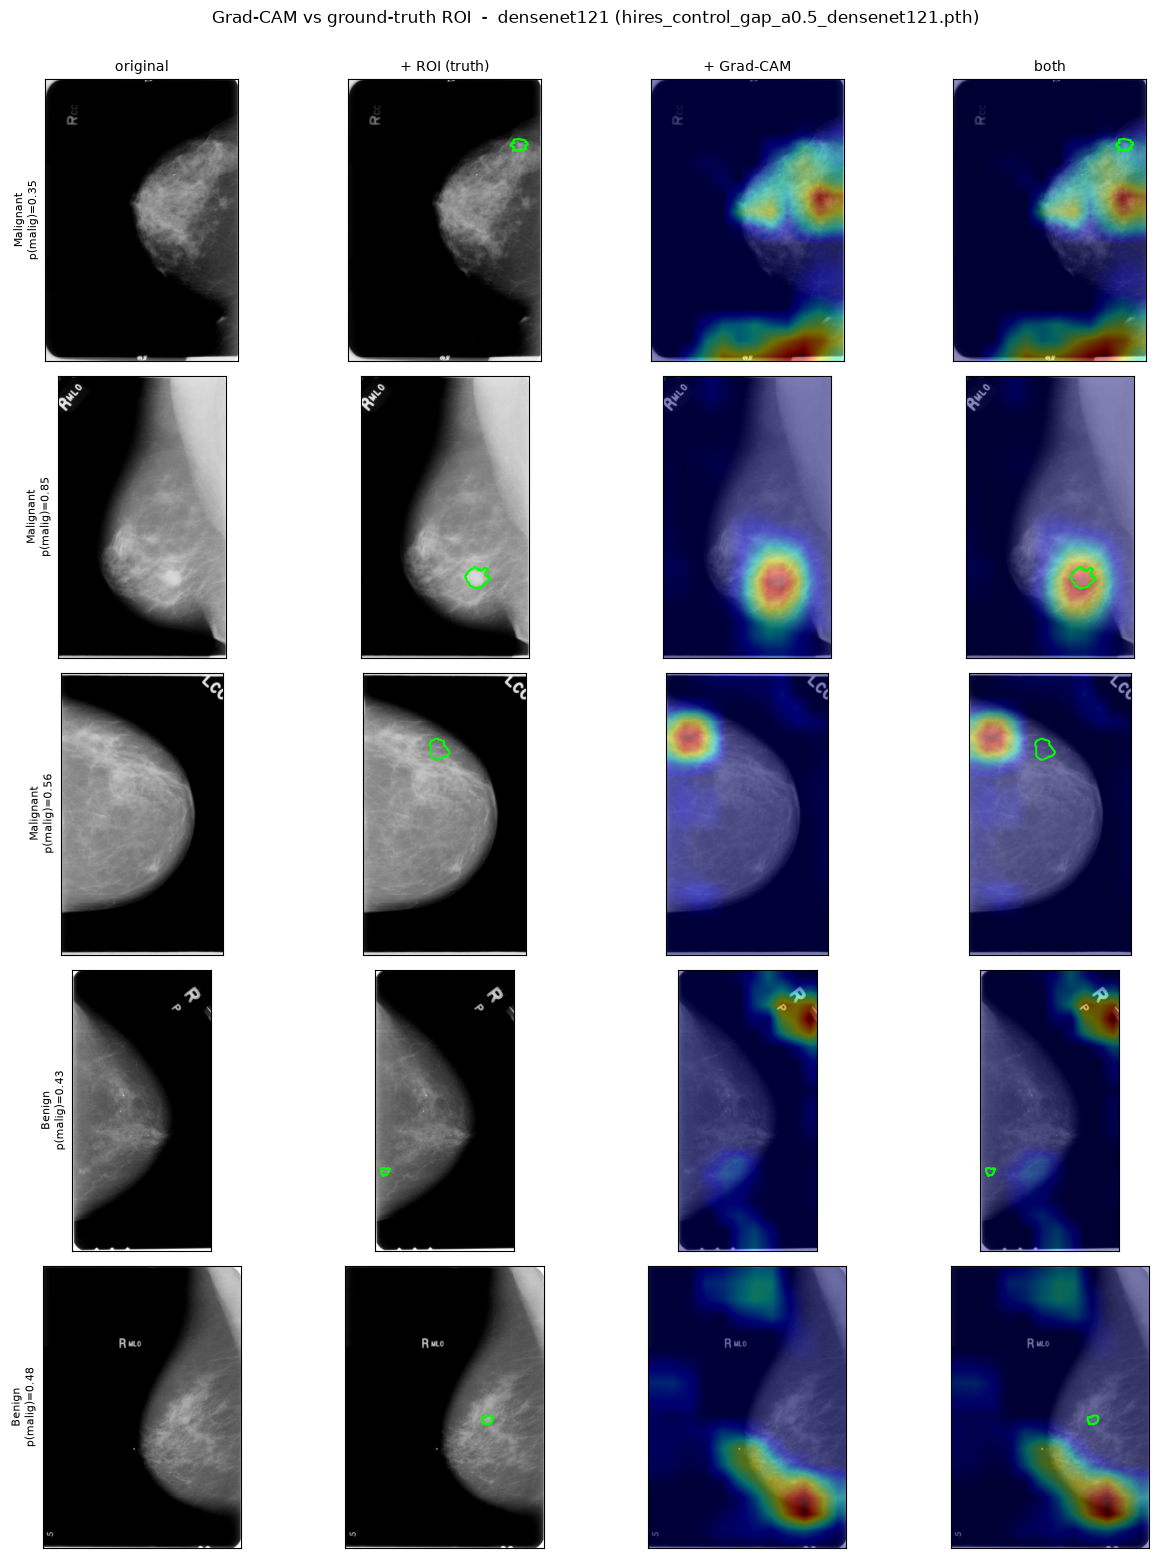

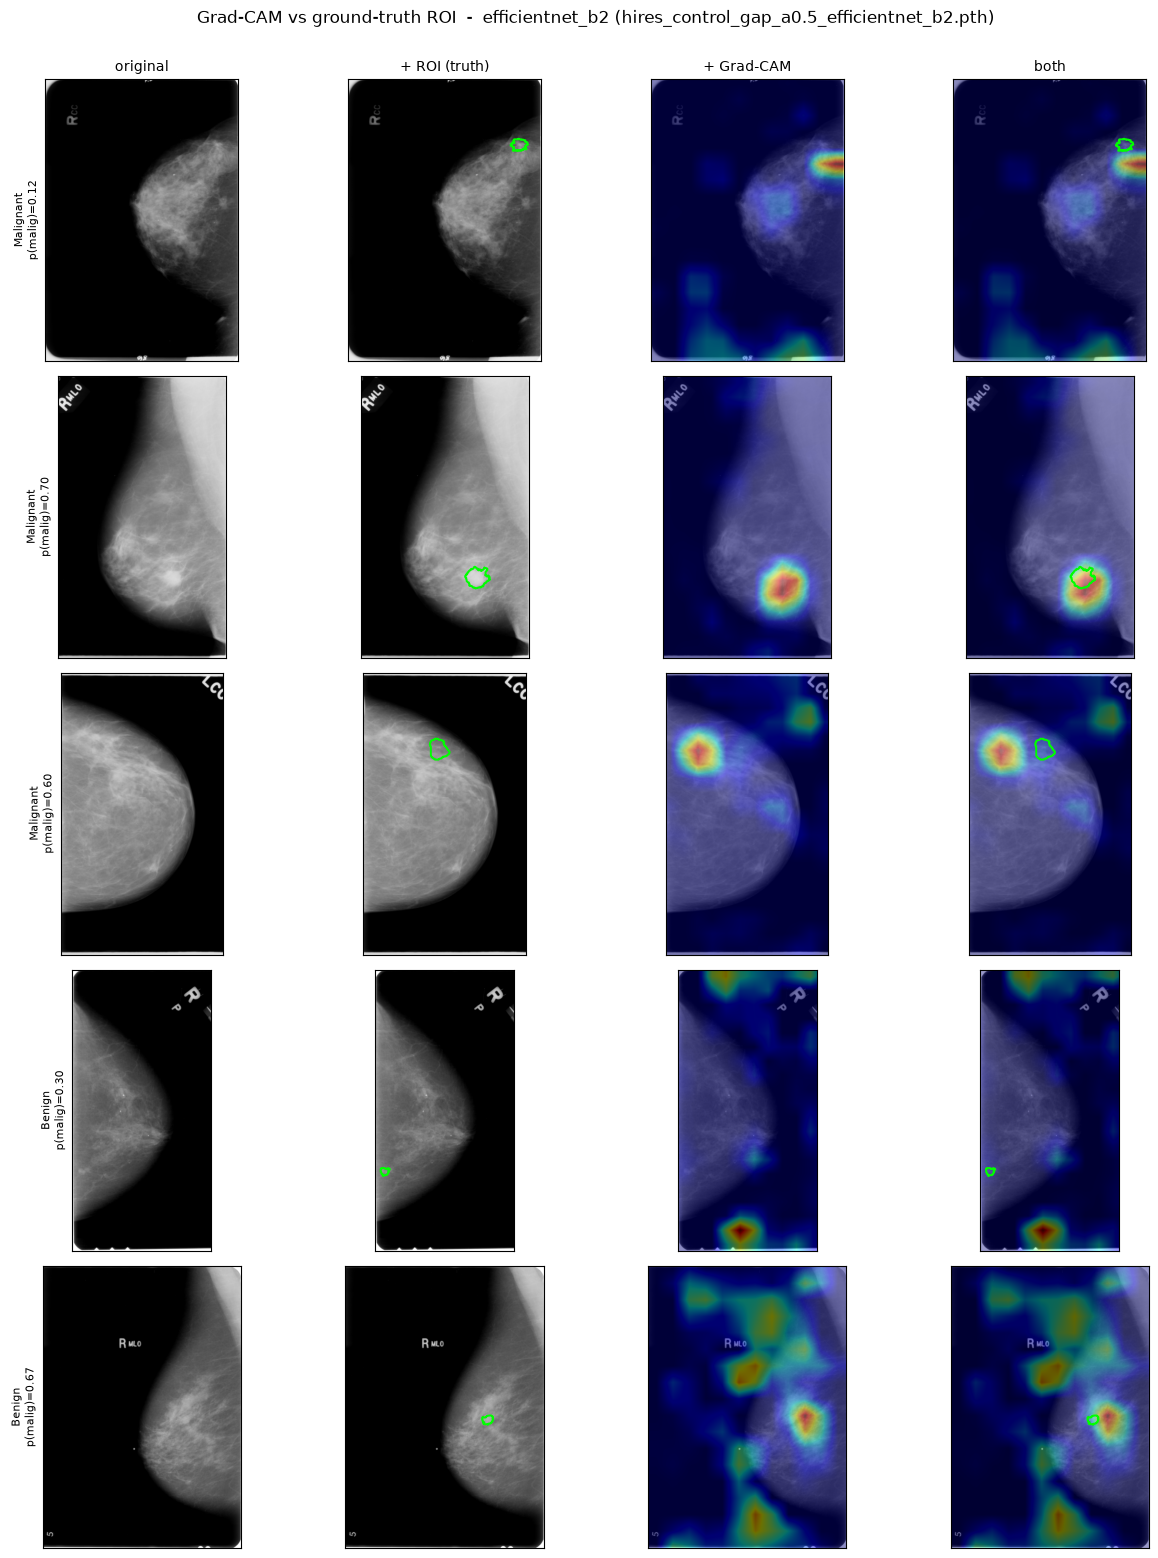

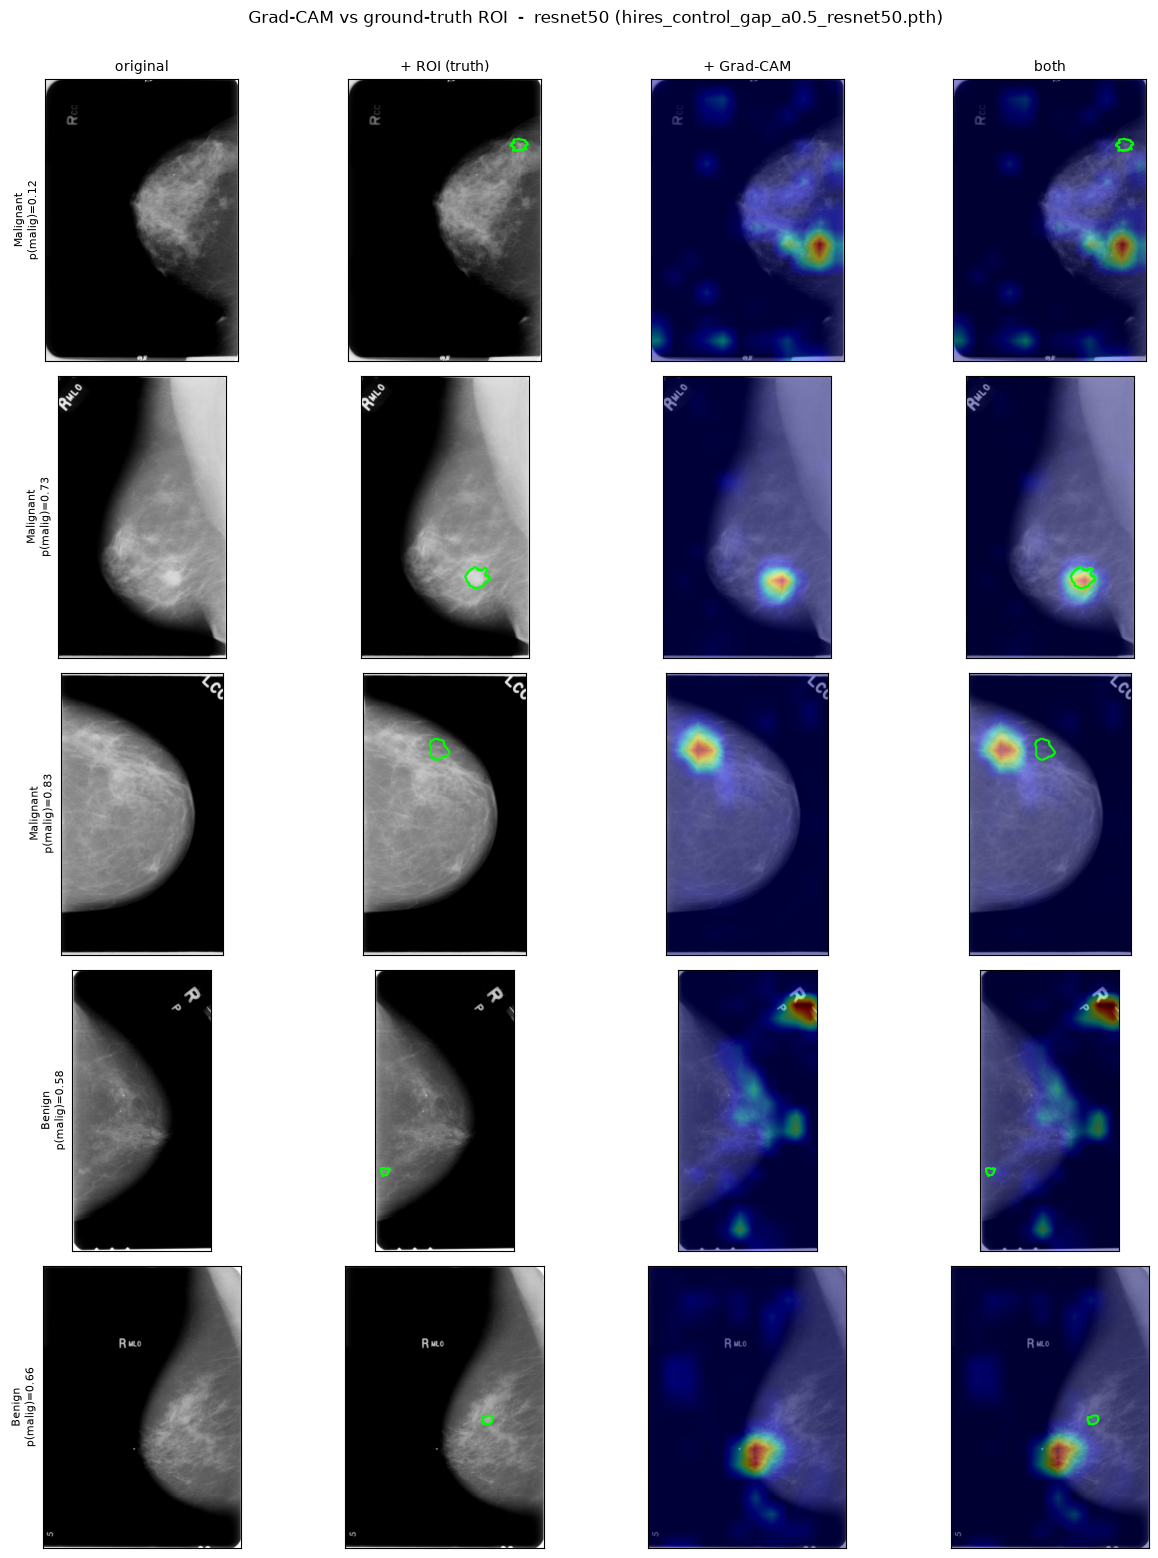

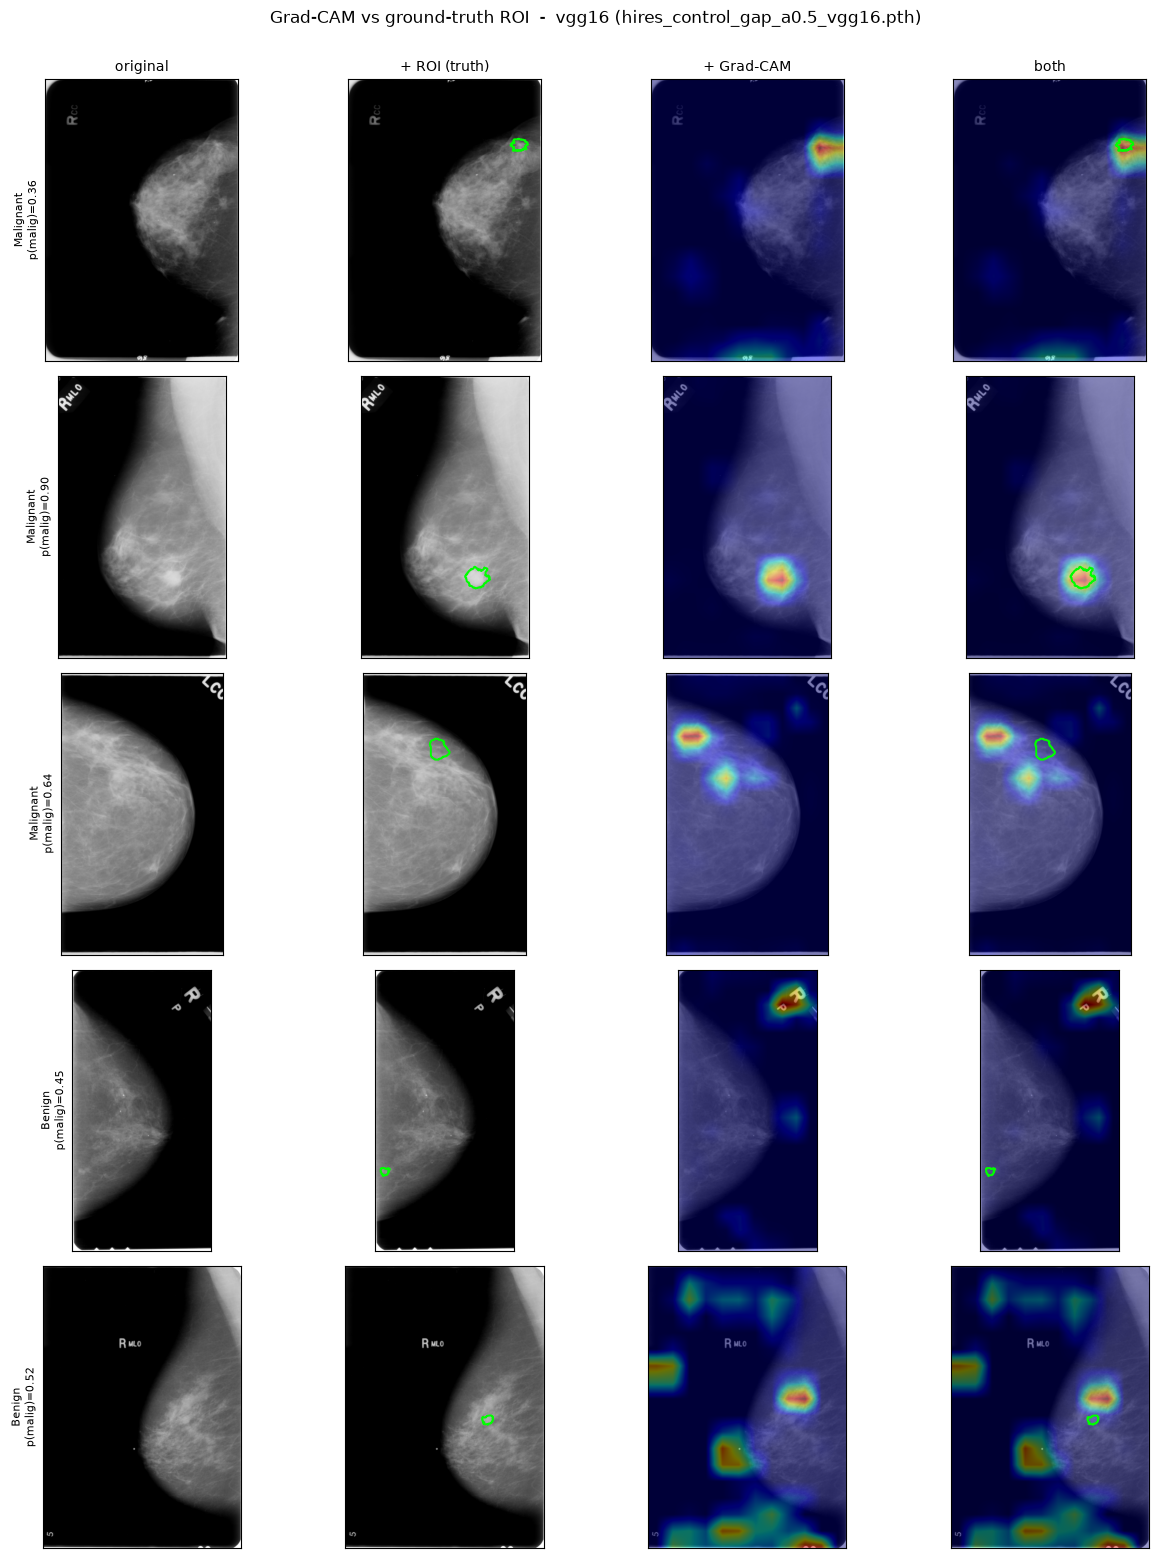

In [53]:
DISP_DIV = 6      # display downscale; a full-res float heatmap per panel would exhaust host RAM


def overlay_panel(row, cam_fn, ax_row, show_titles=False):
    src = source_path(row)
    with Image.open(winlong(src)) as im:
        pil = im.convert("L")
        ow, oh = pil.size
        dw, dh = ow // DISP_DIV, oh // DISP_DIV
        disp = np.asarray(pil.resize((dw, dh), Image.BILINEAR), np.float32) / 255.0

    prob, heat_full = explain(src, cam_fn)
    heat = np.asarray(Image.fromarray(heat_full, mode="F").resize((dw, dh), Image.BILINEAR),
                      np.float32)
    del heat_full                       # ~61MB at full res -- release immediately

    # the cached mask lives in PADDED space; strip the padding before display
    nw, nh, ox, oy = H.fit_pad_geometry(ow, oh)
    core = load_mask(row)[oy:oy + nh, ox:ox + nw].astype(np.float32)
    mask_d = np.asarray(Image.fromarray(core, mode="F").resize((dw, dh), Image.NEAREST)) > 0.5

    truth = "Malignant" if H.encode_label(row[H.LABEL_COL]) == 1 else "Benign"
    ax_row[0].imshow(disp, cmap="gray")
    ax_row[1].imshow(disp, cmap="gray")
    ax_row[1].contour(mask_d, [0.5], colors="lime", linewidths=1.4)
    ax_row[2].imshow(disp, cmap="gray")
    ax_row[2].imshow(heat, cmap="jet", alpha=0.45)
    ax_row[3].imshow(disp, cmap="gray")
    ax_row[3].imshow(heat, cmap="jet", alpha=0.40)
    ax_row[3].contour(mask_d, [0.5], colors="lime", linewidths=1.4)
    if show_titles:
        for a, t in zip(ax_row, ["original", "+ ROI (truth)", "+ Grad-CAM", "both"]):
            a.set_title(t, fontsize=10)
    ax_row[0].set_ylabel(f"{truth}\np(malig)={prob:.2f}", fontsize=8)
    for a in ax_row:
        a.set_xticks([])
        a.set_yticks([])


# Random draw, not .head() -- the first rows of test_df_hires.csv are whatever order the CSV
# happened to be written in, not a representative sample. Seeded on H.SEED so the same five
# images come up on every rerun. Restricted to rows with a non-empty ROI mask, or the "+ ROI"
# panel would show no contour at all.
num = 10
H.SEED = num
batch_num = num
N_MALIGNANT, N_BENIGN = 3, 2
lab = test_df[H.LABEL_COL].apply(H.encode_label)
has_mask = test_df.apply(lambda r: load_mask(r).any(), axis=1)
pool_mal = test_df[(lab == 1) & has_mask]
pool_ben = test_df[(lab == 0) & has_mask]
show = pd.concat([
    pool_mal.sample(n=min(N_MALIGNANT, len(pool_mal)), random_state=H.SEED),
    pool_ben.sample(n=min(N_BENIGN, len(pool_ben)), random_state=H.SEED),
]).reset_index(drop=True)
print(f"showing {len(show)} images (seed={H.SEED}): "
      f"{show[H.LABEL_COL].apply(H.encode_label).map({1: 'malignant', 0: 'benign'}).tolist()}")

for arch in ARCHS:
    m, note = load_model(arch=arch)
    fig, axes = plt.subplots(len(show), 4, figsize=(13, 3.1 * len(show)))
    with H.GradCAM(m) as cf:
        for i, (_, row) in enumerate(show.iterrows()):
            overlay_panel(row, cf, axes[i], show_titles=(i == 0))
    plt.suptitle(f"Grad-CAM vs ground-truth ROI  -  {note}", y=1.002)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"batch_{batch_num}",f"gradcam_overlay_grid_{arch}.png"), dpi=110,
                bbox_inches="tight")
    plt.show()
    del m
    H.free_gpu()

## 5. Does the heatmap agree with the ROI? (measured, all 4 architectures)

Run once per checkpoint in `ARCHS` (`densenet121`, `efficientnet_b2`, `resnet50`, `vgg16`) so the
result is an architecture comparison, not a claim about one backbone.

| metric | what it says |
|---|---|
| **Pointing game** | does the single hottest pixel fall inside the lesion? the standard WSOL metric |
| **Pointing @15px** | same, forgiving a one-cell upsampling offset |
| **Energy concentration** | fraction of total heat landing on the lesion; threshold-free |
| **Concentration ratio** | the above / chance -- *"N times more attention on the lesion than random"*. The headline. |
| **Pixel AP / AUROC** | heat values as scores against the mask; threshold-free |
| **Peak-in-padding** | diagnostic: if high, the model keys on canvas geometry rather than tissue |

Computed in 384x640 space where the mask already lives -- mathematically equivalent to computing at
original resolution and vastly cheaper than materializing a 61 MB float array per image.

In [ ]:
# def evaluate_localization(df, cam_fn, class_idx=1, limit=None, desc="localization"):
#     """`row_idx` records which source row each result came from. The skip condition below depends
#     only on the mask, so every architecture yields the same rows in the same order -- but section 6
#     runs PAIRED tests on these frames, so that is asserted rather than assumed."""
#     rows = []
#     it = df if limit is None else df.head(limit)
#     for i, row in tqdm(it.iterrows(), total=len(it), desc=desc, leave=False):
#         mask = load_mask(row)
#         if not mask.any():
#             continue
#         cam, prob = cam_for_row(row, cam_fn, class_idx)
#         v = H.validity_mask(*source_size(row))
#         m = H.localization_metrics(cam, mask, v)
#         for tau in (0.3, 0.5, 0.7):
#             m[f"iou@{tau}"] = H.iou_at(cam, mask, v, tau)
#         m.update(row_idx=i, prob_malignant=prob, label=H.encode_label(row[H.LABEL_COL]))
#         rows.append(m)
#     return pd.DataFrame(rows)


# def summarize(d, name):
#     return {"model": name, "n": len(d),
#             "pointing_%": 100 * d["pointing_hit"].mean(),
#             "pointing@15px_%": 100 * d["pointing_hit_tol"].mean(),
#             "energy_conc": d["energy_concentration"].mean(),
#             "conc_ratio_x": d["concentration_ratio"].mean(),
#             "pixel_ap": d["pixel_ap"].mean(),
#             "pixel_auroc": d["pixel_auroc"].mean(),
#             "iou@0.5": d["iou@0.5"].mean(),
#             "peak_in_padding_%": 100 * d["peak_in_padding"].mean(),
#             "median_peak_dist_px": d["peak_dist_px"].median()}


# ALL_LOC = {}
# for arch in ARCHS:
#     m, note = load_model(arch=arch)
#     with H.GradCAM(m) as cf:
#         d = evaluate_localization(test_df, cf, desc=f"test localization ({arch})")
#     d.to_csv(os.path.join(RESULTS_DIR, f"localization_{MODE}_{arch}.csv"), index=False)
#     ALL_LOC[arch] = d
#     del m
#     H.free_gpu()

# # every architecture must have scored the SAME images in the SAME order, or section 6's paired
# # tests silently compare unrelated pairs
# _ref = ALL_LOC[ARCHS[0]]["row_idx"].tolist()
# for arch in ARCHS[1:]:
#     assert ALL_LOC[arch]["row_idx"].tolist() == _ref, f"{arch} evaluated a different row set"
# print(f"all {len(ARCHS)} architectures scored the same {len(_ref)} images -- results are paired\n")

# pd.set_option("display.width", 200)
# summary_tbl = pd.DataFrame([summarize(d, arch) for arch, d in ALL_LOC.items()])
# print(summary_tbl.to_string(index=False))
# summary_tbl.to_csv(os.path.join(RESULTS_DIR, f"localization_summary_{MODE}_all_archs.csv"),
#                    index=False)

test localization (densenet121):   0%|          | 0/319 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Reading the numbers above

Two reference points make `conc_ratio_x` meaningful: **1.00x** is chance, and the random-init score
for the same architecture from section 3 is the floor a *trained* model has to clear. A model near
either is not localizing, whatever its accuracy.

What the harness has established by this point, independent of any architecture: sizes round-trip
exactly (section 1), CAM peaks track a known input patch in both axes (section 3b), and a random
model scores at chance (section 3a). So differences between the four backbones below are real
differences in what they learned, not artifacts of the measurement.

Eyeballing which column is largest is not enough -- with n~319 and heavily skewed per-image ratios,
adjacent architectures can differ by a lot in the mean and not at all in reality. Section 6 tests
it.

## 6. Which architecture is the most interpretable?

All four were evaluated on the **same test images in the same order** (asserted in section 5), so
this is a paired comparison and paired tests apply -- far more powerful than checking whether
bootstrap CIs overlap, because per-image difficulty cancels out.

**Wilcoxon signed-rank, not a t-test.** The per-image concentration ratio is bounded below at 0 and
has a long right tail; normality is not a safe assumption at any n.

**Holm-Bonferroni correction.** Four architectures means six pairwise tests. Uncorrected, the
chance of at least one spurious "significant" result is ~26%, and picking a winner out of six
uncorrected tests is exactly how a noise result gets into a thesis. Holm controls the family-wise
error rate at 5% while staying more powerful than plain Bonferroni.

**One headline metric, decided in advance: `concentration_ratio`.** Ranking by whichever of six
metrics is most flattering is a garden-of-forking-paths problem. The rank-agreement table below
exists to check the winner is not an artifact of that one choice -- if the metrics disagree, that
disagreement is the finding and should be reported rather than resolved by picking a favourite.

In [ ]:
# from itertools import combinations
# from scipy import stats

# PRIMARY = "concentration_ratio"      # fixed in advance -- see the note above


# def holm(pvals):
#     """Holm-Bonferroni step-down adjusted p-values. Uniformly more powerful than Bonferroni at the
#     same family-wise error rate, so there is no reason to prefer the latter."""
#     p = np.asarray(pvals, float)
#     order = np.argsort(p)
#     adj, running, m = np.empty_like(p), 0.0, len(p)
#     for i, idx in enumerate(order):
#         running = max(running, (m - i) * p[idx])
#         adj[idx] = min(running, 1.0)
#     return adj


# # --- ranking on the headline metric, with bootstrap CIs ---
# paired = pd.DataFrame({a: ALL_LOC[a][PRIMARY].values for a in ARCHS})
# ranked = paired.mean().sort_values(ascending=False).index.tolist()

# rng = np.random.default_rng(H.SEED)
# rank_rows = []
# for arch in ranked:
#     v = paired[arch].dropna().values
#     boot = np.array([rng.choice(v, len(v), replace=True).mean() for _ in range(2000)])
#     d = ALL_LOC[arch]
#     rank_rows.append({"arch": arch, "conc_ratio_x": v.mean(),
#                       "ci_lo": np.percentile(boot, 2.5), "ci_hi": np.percentile(boot, 97.5),
#                       "pointing_%": 100 * d["pointing_hit"].mean(),
#                       "pixel_ap": d["pixel_ap"].mean(),
#                       "pixel_auroc": d["pixel_auroc"].mean(),
#                       "peak_in_pad_%": 100 * d["peak_in_padding"].mean()})
# rank_tbl = pd.DataFrame(rank_rows)
# print("RANKED BY CONCENTRATION RATIO (chance = 1.00x)")
# print(rank_tbl.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# # --- all 6 pairwise paired tests ---
# pair_rows, raw_p = [], []
# for a, b in combinations(ranked, 2):
#     va, vb = ALL_LOC[a][PRIMARY], ALL_LOC[b][PRIMARY]
#     _, p = stats.wilcoxon(va, vb, nan_policy="omit")
#     raw_p.append(p)
#     pair_rows.append({"better": a, "worse": b, "delta_x": va.mean() - vb.mean(),
#                       "win_rate_%": 100 * (va > vb).mean(), "p_raw": p})
# pair_tbl = pd.DataFrame(pair_rows)
# pair_tbl["p_holm"] = holm(raw_p)
# pair_tbl["signif"] = np.where(pair_tbl["p_holm"] < 0.05, "yes", "no")
# print("\nPAIRWISE (Wilcoxon signed-rank, Holm-corrected across all 6 tests)")
# print(pair_tbl.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# # --- does the winner survive a change of metric? ---
# higher_better = {"concentration_ratio": True, "energy_concentration": True, "pointing_hit": True,
#                  "pointing_hit_tol": True, "pixel_ap": True, "pixel_auroc": True,
#                  "iou@0.5": True, "peak_dist_px": False}
# agree = pd.DataFrame(
#     {met: pd.Series({a: ALL_LOC[a][met].mean() for a in ARCHS})
#             .rank(ascending=not hi).astype(int)
#      for met, hi in higher_better.items()})
# agree["mean_rank"] = agree.mean(axis=1)
# print("\nRANK BY METRIC (1 = best; mean_rank low = consistently good)")
# print(agree.sort_values("mean_rank").to_string())

# rank_tbl.to_csv(os.path.join(RESULTS_DIR, "interpretability_ranking.csv"), index=False)
# pair_tbl.to_csv(os.path.join(RESULTS_DIR, "interpretability_pairwise.csv"), index=False)

In [ ]:
# # --- is the most interpretable model also the most accurate? ---
# # Accuracy comes from the training sweep, not recomputed here; same checkpoints, same test split.
# runs = pd.read_csv(os.path.join(ROOT, "notebooks", "experiment_1_baseline", "results",
#                                 "hires_runs.csv"))
# acc = runs.set_index("architecture")[["accuracy", "roc_auc"]]

# verdict = rank_tbl.set_index("arch").join(acc)
# assert not verdict[["accuracy", "roc_auc"]].isna().any().any(), \
#     "accuracy join produced NaN -- an arch name in ARCHS is missing from hires_runs.csv"
# verdict["interp_rank"] = verdict["conc_ratio_x"].rank(ascending=False).astype(int)
# verdict["acc_rank"] = verdict["roc_auc"].rank(ascending=False).astype(int)
# print("INTERPRETABILITY vs CLASSIFICATION PERFORMANCE")
# print(verdict[["conc_ratio_x", "ci_lo", "ci_hi", "interp_rank", "accuracy", "roc_auc",
#                "acc_rank"]].to_string(float_format=lambda x: f"{x:.3f}"))

# # McNemar on the pointing game for the top two -- a second, binary confirmation of the winner
# top, second = ranked[0], ranked[1]
# x = ALL_LOC[top]["pointing_hit"].values.astype(bool)
# y = ALL_LOC[second]["pointing_hit"].values.astype(bool)
# n01, n10 = int((~x & y).sum()), int((x & ~y).sum())
# p_mc = stats.binomtest(min(n01, n10), n01 + n10, 0.5).pvalue if (n01 + n10) else 1.0
# print(f"\nMcNemar, pointing game, {top} vs {second}: "
#       f"{top} wins {n10}, {second} wins {n01}, p = {p_mc:.4f}")

# # --- the verdict, stated rather than left to the reader ---
# beats = pair_tbl[(pair_tbl["better"] == top) & (pair_tbl["signif"] == "yes")]["worse"].tolist()
# print(f"\n{'=' * 78}\nMOST INTERPRETABLE: {top}  "
#       f"({verdict.loc[top, 'conc_ratio_x']:.2f}x chance, 95% CI "
#       f"[{verdict.loc[top, 'ci_lo']:.2f}, {verdict.loc[top, 'ci_hi']:.2f}])")
# if beats:
#     print(f"  significantly beats (Holm-corrected): {', '.join(beats)}")
#     ties = [a for a in ranked[1:] if a not in beats]
#     if ties:
#         print(f"  NOT separable from: {', '.join(ties)} -- report these as tied, not ranked")
# else:
#     print("  but beats NO other architecture significantly after correction.")
#     print("  The correct claim is that the four are statistically indistinguishable on")
#     print("  localization -- report the ranking as descriptive only.")
# srho = stats.spearmanr(verdict["conc_ratio_x"], verdict["roc_auc"]).statistic
# print(f"\nSpearman(interpretability, AUC) = {srho:.2f} over n=4 architectures -- far too few "
#       "points\nfor this to be evidence either way; report it as an observation, not a trend.")
# print("=" * 78)

In [ ]:
# fig, (ax_bar, ax_sc) = plt.subplots(1, 2, figsize=(13, 4.2))

# # --- ranked magnitude with uncertainty ---
# order = ranked[::-1]                                   # best at top
# y = np.arange(len(order))
# means = np.array([verdict.loc[a, "conc_ratio_x"] for a in order])
# lo = means - np.array([verdict.loc[a, "ci_lo"] for a in order])
# hi = np.array([verdict.loc[a, "ci_hi"] for a in order]) - means

# ax_bar.barh(y, means, height=0.62, color=[ARCH_COLOR[a] for a in order])
# ax_bar.errorbar(means, y, xerr=[lo, hi], fmt="none", ecolor=INK, elinewidth=1.4, capsize=4)
# ax_bar.axvline(1.0, color=MUTED, ls="--", lw=1.2)
# ax_bar.text(1.0, len(order) - 0.35, " chance", color=MUTED, fontsize=8, va="center")
# for yi, mval in enumerate(means):        # direct labels -- identity/value never colour-alone
#     ax_bar.text(mval + hi[yi] + 0.06, yi, f"{mval:.2f}x", va="center", fontsize=9, color=INK)
# ax_bar.set_yticks(y, order, fontsize=9)
# ax_bar.set_xlabel("concentration ratio (x chance)", color=MUTED, fontsize=9)
# ax_bar.set_title("Localization quality, ranked  (95% CI)", fontsize=10, loc="left")
# ax_bar.set_xlim(0, (means + hi).max() * 1.22)

# # --- interpretability vs accuracy: two measures on ONE scatter, never a dual y-axis ---
# for a in ARCHS:
#     ax_sc.scatter(verdict.loc[a, "roc_auc"], verdict.loc[a, "conc_ratio_x"],
#                   s=110, color=ARCH_COLOR[a], zorder=3, edgecolor="white", linewidth=1.5)
#     ax_sc.annotate(a, (verdict.loc[a, "roc_auc"], verdict.loc[a, "conc_ratio_x"]),
#                    textcoords="offset points", xytext=(9, 0), fontsize=8.5, color=INK,
#                    va="center")
# ax_sc.axhline(1.0, color=MUTED, ls="--", lw=1.2)
# ax_sc.set_xlabel("test ROC AUC (classification)", color=MUTED, fontsize=9)
# ax_sc.set_ylabel("concentration ratio (explanation)", color=MUTED, fontsize=9)
# ax_sc.set_title("Does accuracy buy interpretability?", fontsize=10, loc="left")
# ax_sc.margins(x=0.24)

# for ax in (ax_bar, ax_sc):
#     ax.grid(axis="x" if ax is ax_bar else "both", color=GRID, lw=0.8)
#     ax.set_axisbelow(True)
#     for s in ("top", "right"):
#         ax.spines[s].set_visible(False)
#     for s in ("left", "bottom"):
#         ax.spines[s].set_color(GRID)
#     ax.tick_params(colors=MUTED, labelsize=8.5)
# ax_bar.tick_params(axis="y", colors=INK, labelsize=9)

# plt.tight_layout()
# plt.savefig(os.path.join(FIG_DIR, "interpretability_ranking.png"), dpi=150, bbox_inches="tight")
# plt.show()

## 7. Control vs seg-aux (paired)

Section 6 asks which *backbone* explains best. This section asks a different question: for a fixed
backbone, does **auxiliary ROI-mask supervision produce better explanations**? Same paired logic,
same tests -- McNemar's exact for the binary pointing game, Wilcoxon signed-rank for the continuous
metrics.

**Two fairness rules, or the comparison is worthless:**

1. The seg-aux model's CAM must come from the **classifier** path -- gradients of the class-1 logit
   w.r.t. `extractor` -- *not* from the segmentation decoder's output. Otherwise you are comparing a
   segmentation model's segmentation against a classifier's Grad-CAM, which is not the claim. The
   decoder output may be reported separately as a clearly labelled auxiliary-localization row.
2. Both models must share architecture, resolution, batch size, epoch budget, seed and pooling.
   Only the seg loss term differs.

No hi-res seg-aux checkpoint exists yet, so this no-ops. When they are trained, run it once per
architecture -- whether seg-aux helps is itself likely to be backbone-dependent, and a single
architecture cannot answer it.

In [ ]:
# COMPARE = {
#     # "control": "<path to hi-res control checkpoint>",
#     # "segaux":  "<path to hi-res segaux checkpoint>",
# }

# if len(COMPARE) < 2:
#     print("Set COMPARE to two hi-res checkpoints (same architecture) to run the paired comparison.")
# else:
#     results, archs_seen = {}, set()
#     for name, path in COMPARE.items():
#         ck = torch.load(path, map_location=H.DEVICE, weights_only=False)
#         assert list(ck.get("input_size", [])) == [H.HIRES_H, H.HIRES_W], f"{name}: wrong input_size"
#         # architecture comes from the checkpoint -- hardcoding it here would silently compare a
#         # control of one backbone against a segaux of another
#         arch_name = ck["arch"]
#         archs_seen.add(arch_name)
#         m = H.SingleInputModel(arch_name, pooling=ck.get("pooling", "gap"),
#                                use_seg=ck.get("use_seg", False)).to(H.DEVICE)
#         m.load_state_dict(ck["model_state_dict"])
#         m.eval()
#         with H.GradCAM(m) as cf:            # classifier path, NOT the seg decoder
#             results[name] = evaluate_localization(test_df, cf, desc=f"{name} ({arch_name})")
#         del m
#         H.free_gpu()
#     assert len(archs_seen) == 1, f"COMPARE mixes architectures {archs_seen} -- not a fair pairing"

#     a, b = list(COMPARE)
#     da, db = results[a], results[b]
#     assert da["row_idx"].tolist() == db["row_idx"].tolist(), "row sets differ -- not paired"
#     print(pd.DataFrame([summarize(da, a), summarize(db, b)]).to_string(index=False))

#     x, y = da["pointing_hit"].values.astype(bool), db["pointing_hit"].values.astype(bool)
#     n01, n10 = int((~x & y).sum()), int((x & ~y).sum())
#     p_mc = stats.binomtest(min(n01, n10), n01 + n10, 0.5).pvalue if (n01 + n10) else 1.0
#     print(f"\nMcNemar (pointing game): {b} wins {n01}, {a} wins {n10}, p = {p_mc:.4f}")

#     for metric in ("energy_concentration", "concentration_ratio", "pixel_ap"):
#         s, p = stats.wilcoxon(da[metric], db[metric], nan_policy="omit")
#         print(f"Wilcoxon {metric:22s}: {a} {da[metric].mean():.4f} vs "
#               f"{b} {db[metric].mean():.4f}   p = {p:.4f}")

## 8. What to record for the thesis

- **Report all four architectures, not the winner alone.** The ranking table plus the
  Holm-corrected pairwise tests from section 6 are the result. "X localizes best" is only a claim
  if it survives correction; otherwise the honest sentence is *"the four are statistically
  indistinguishable on localization"*, which is itself worth stating.
- **Concentration ratio is the headline**: *"the heatmap places N times more attention on the lesion
  than chance"* -- threshold-free, scale-invariant, immediately interpretable.
- **Report the IoU curve, not a single IoU.** With a target under 1% of the image, absolute IoU is
  low by construction and a single number invites a misreading.
- **Bootstrap 95% CIs on every headline figure, per architecture.** At n=319 the SE on a proportion
  is ~2.6 pp, so a bare point estimate is not defensible.
- **Report the peak-in-padding rate even when it is near zero** -- it demonstrates the model is not
  exploiting the canvas.
- **Interpretability and accuracy are separate axes.** If the most interpretable backbone is not the
  most accurate, say so plainly -- with n=4 architectures there is no statistical basis for calling
  it a trade-off, but it is a legitimate observation and a reason to pick a deployment model on
  something other than AUC alone.
- If seg-aux improves localization but not accuracy, **report exactly that**. Explainability gained
  at no accuracy cost is a real, publishable result; do not reshape it into an accuracy story.